# Import Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura dos Dados

In [2]:
# Importando conjunto de dados
df_loja = pd.read_excel('tabela_estrutura_lojas.xlsx' , engine='openpyxl')

# Verificando dados ausentes e dtype de cada variavel
df_loja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CODIGO_LOJA        5 non-null      int64 
 1   NOME_SUPERMERCADO  5 non-null      object
dtypes: int64(1), object(1)
memory usage: 208.0+ bytes


In [3]:
# Importando conjunto de dados
df_perfil = pd.read_excel('tabela_perfil_clientes.xlsx' , engine='openpyxl')

# Verificando dados ausentes e dtype de cada variavel
df_perfil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37294 entries, 0 to 37293
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CODIGO_CLIENTE         37294 non-null  int64 
 1   PERFIL_SUPERMERCADO_A  37294 non-null  object
 2   PERFIL_SUPERMERCADO_B  37294 non-null  object
dtypes: int64(1), object(2)
memory usage: 874.2+ KB


In [4]:
# Importando conjunto de dados
df_vendas = pd.read_excel('tabela_vendas.xlsx' , engine='openpyxl')

# Verificando dados ausentes e dtype de cada variavel
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250378 entries, 0 to 250377
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MES                  250378 non-null  object 
 1   CODIGO_LOJA          250378 non-null  int64  
 2   CODIGO_CUPOM_FISCAL  250378 non-null  int64  
 3   CODIGO_CLIENTE       250378 non-null  int64  
 4   NOME_CATEGORIA       250378 non-null  object 
 5   FATURAMENTO_BRUTO    250378 non-null  float64
 6   UNIDADES_VENDIDAS    250378 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 13.4+ MB


É possivel verificar que não existe dados nulls nas tabelas e que o types de cada coluna estão compativeis

## Joins entre as Bases de Dados

In [5]:
#joins
df = df_vendas.merge(df_loja , on=['CODIGO_LOJA'] , how='left')
df = df.merge(df_perfil , on=['CODIGO_CLIENTE'] , how='left')

# ajuste ordenação variaveis
df = df[['MES', 'CODIGO_LOJA', 'NOME_SUPERMERCADO' ,'CODIGO_CUPOM_FISCAL',
        'CODIGO_CLIENTE','PERFIL_SUPERMERCADO_A', 'PERFIL_SUPERMERCADO_B',
       'NOME_CATEGORIA', 'FATURAMENTO_BRUTO', 'UNIDADES_VENDIDAS']]

In [6]:
# Validação Join
df.head()

,MES,CODIGO_LOJA,NOME_SUPERMERCADO,CODIGO_CUPOM_FISCAL,CODIGO_CLIENTE,PERFIL_SUPERMERCADO_A,PERFIL_SUPERMERCADO_B,NOME_CATEGORIA,FATURAMENTO_BRUTO,UNIDADES_VENDIDAS
0,FEVEREIRO,228,SUPERMERCADO A,9347524529,2088692,ALTO POTENCIAL,FUTURO ABANDONADOR,BEBIDAS,12.46,4
1,FEVEREIRO,223,SUPERMERCADO A,9335646941,22938554,FUTURO ABANDONADOR,DESCOMPROMISSADO,CESTA BASICA,7.99,1
2,JANEIRO,228,SUPERMERCADO A,9331811768,2538335,DESCOMPROMISSADO,BAIXO POTENCIAL,CESTA BASICA,20.89,10
3,JANEIRO,228,SUPERMERCADO A,9317006932,7498689,DESCOMPROMISSADO,FUTURO ABANDONADOR,HIGIENE E BELEZA,19.86,1
4,JANEIRO,228,SUPERMERCADO A,9331132318,20196738,PREMIUM,ALTO POTENCIAL,MERCEARIA SECA,11.38,2


In [7]:
# Validação Join
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250378 entries, 0 to 250377
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   MES                    250378 non-null  object 
 1   CODIGO_LOJA            250378 non-null  int64  
 2   NOME_SUPERMERCADO      250378 non-null  object 
 3   CODIGO_CUPOM_FISCAL    250378 non-null  int64  
 4   CODIGO_CLIENTE         250378 non-null  int64  
 5   PERFIL_SUPERMERCADO_A  250378 non-null  object 
 6   PERFIL_SUPERMERCADO_B  250378 non-null  object 
 7   NOME_CATEGORIA         250378 non-null  object 
 8   FATURAMENTO_BRUTO      250378 non-null  float64
 9   UNIDADES_VENDIDAS      250378 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 19.1+ MB


## Analise e resposta de cada perguntada

### 1 – Qual o diagnóstico de crescimento/retração de vendas do grupo varejista no mês de  fevereiro? Qual a rede varejista que puxa o resultado? O Supermercado A ou Supermercado B?

In [8]:
# Filtrando datasetes para criar conjuntos de dados somente com registros de janeiro para cada supermercado
df_jan = df[df['MES'] == 'JANEIRO'].reset_index(drop=True)
df_jan_superA = df_jan[df_jan['NOME_SUPERMERCADO'] == 'SUPERMERCADO A'].reset_index()
df_jan_superB = df_jan[df_jan['NOME_SUPERMERCADO'] == 'SUPERMERCADO B'].reset_index()

# Filtrando datasetes para criar conjuntos de dados somente com registros de fevereiro para cada supermercado
df_fev = df[df['MES'] == 'FEVEREIRO'].reset_index(drop=True)
df_fev_superA = df_fev[df_fev['NOME_SUPERMERCADO'] == 'SUPERMERCADO A'].reset_index()
df_fev_superB = df_fev[df_fev['NOME_SUPERMERCADO'] == 'SUPERMERCADO B'].reset_index()

# Calculo faturamento bruto jan e feveiro
faturamento_bruto_jan = df_jan['FATURAMENTO_BRUTO'].sum()
faturamento_bruto_fev = df_fev['FATURAMENTO_BRUTO'].sum()

# Calculo faturamento bruto jan para supermercado A e B separados
faturamento_bruto_jan_superA = df_jan_superA['FATURAMENTO_BRUTO'].sum()
faturamento_bruto_jan_superB = df_jan_superB['FATURAMENTO_BRUTO'].sum()

# Calculo faturamento bruto fev para supermercado A e B separados
faturamento_bruto_fev_superA = df_fev_superA['FATURAMENTO_BRUTO'].sum()
faturamento_bruto_fev_superB = df_fev_superB['FATURAMENTO_BRUTO'].sum()

# Calculo vendas jan e feveiro
vendas_jan = df_jan['UNIDADES_VENDIDAS'].sum()
vendas_fev = df_fev['UNIDADES_VENDIDAS'].sum()

# Calculo vendas jan para supermercado A e B separados
vendas_jan_superA = df_jan_superA['UNIDADES_VENDIDAS'].sum()
vendas_jan_superB = df_jan_superB['UNIDADES_VENDIDAS'].sum()

# Calculo vendas fev para supermercado A e B separados
vendas_fev_superA = df_fev_superA['UNIDADES_VENDIDAS'].sum()
vendas_fev_superB = df_fev_superB['UNIDADES_VENDIDAS'].sum()

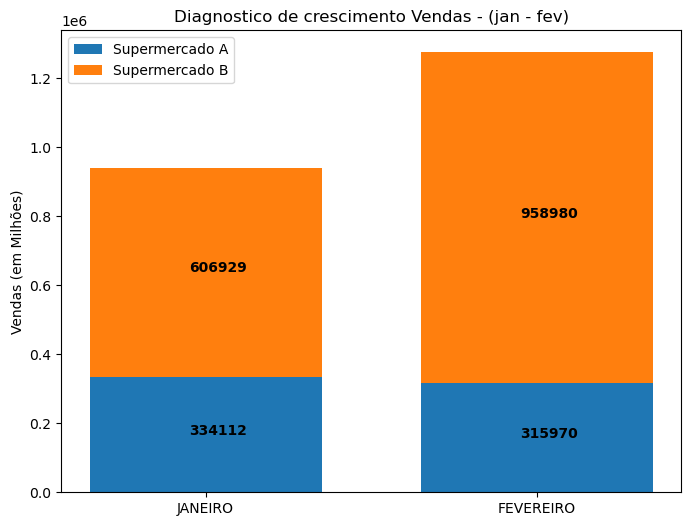

In [9]:
# Plot grafico analise crescimento faturamento
# Import biblioteca
import matplotlib.pyplot as plt

# Dados para a primeira barra
supermercado_A = [vendas_jan_superA, vendas_fev_superA]
supermercado_B = [vendas_jan_superB, vendas_fev_superB]
atividades = ['JANEIRO', 'FEVEREIRO']


# Configuração do gráfico
fig, ax = plt.subplots(figsize=(8,6))
largura = 0.7  # Largura das barras
posicao1 = [0, 1]  # Posição das barras da primeira barra
posicao2 = [x + x for x in posicao1]  # Posição das barras da segunda barra
ax.set_xticks(posicao1)
ax.set_xticklabels(atividades)
ax.set_ylabel('Vendas (em Milhões)')

# Plotagem das barras para a primeira barra
ax.bar(posicao1, supermercado_A, width=largura, label='Supermercado A')
ax.bar(posicao1, supermercado_B, width=largura, bottom=supermercado_A, label='Supermercado B')

# Adiciona rótulos às barras
for i, v in enumerate(supermercado_A):
    #ax.text(posicao1[i] - 0.05, v/2 + 1, str(round(v/1000000,3)), color='black', fontweight='bold')
    ax.text(posicao1[i] - 0.05, v/2 + 1, str(v), color='black', fontweight='bold')
for i, v in enumerate(supermercado_B):
    #ax.text(posicao1[i] - 0.05, supermercado_A[i] + v/2 + 1, str(round(v/1000000,3)), color='black', fontweight='bold')
    ax.text(posicao1[i] - 0.05, supermercado_A[i] + v/2 + 1, str(v), color='black', fontweight='bold')
# Legenda
ax.legend()

# Título
ax.set_title('Diagnostico de crescimento Vendas - (jan - fev)')

# Plot
plt.show()

In [10]:
print('Vendas Jan (Unid):', vendas_jan)
print('Vendas Fev (Unid):', vendas_fev)
print()
print('Crescimento Vendas de Jan - Fev de:', str(((vendas_fev/vendas_jan)-1)*100) + '%')
print('Redução Vendas Supermercado A de Jan - Fev de:', str((1- (vendas_fev_superA/vendas_jan_superA))*100) + '%')
print('Aumento Vendas Supermercado B de Jan - Fev de:', str(((vendas_fev_superB/vendas_jan_superB)-1)*100) + '%')

Vendas Jan (Unid): 941041
Vendas Fev (Unid): 1274950

Crescimento Vendas de Jan - Fev de: 35.4829385754712%
Redução Vendas Supermercado A de Jan - Fev de: 5.4299157168853585%
Aumento Vendas Supermercado B de Jan - Fev de: 58.005302102881885%


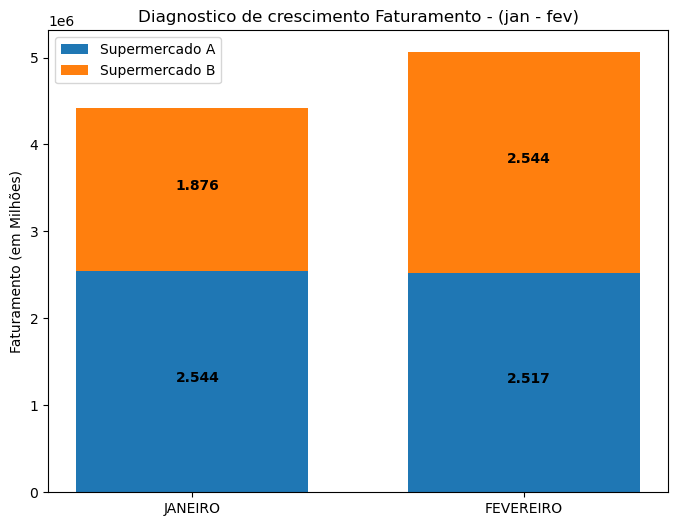

In [11]:
# Plot grafico analise crescimento faturamento
# Import biblioteca
import matplotlib.pyplot as plt

# Dados para a primeira barra
supermercado_A = [faturamento_bruto_jan_superA, faturamento_bruto_fev_superA]
supermercado_B = [faturamento_bruto_jan_superB, faturamento_bruto_fev_superB]
atividades = ['JANEIRO', 'FEVEREIRO']


# Configuração do gráfico
fig, ax = plt.subplots(figsize=(8,6))
largura = 0.7  # Largura das barras
posicao1 = [0, 1]  # Posição das barras da primeira barra
posicao2 = [x + x for x in posicao1]  # Posição das barras da segunda barra
ax.set_xticks(posicao1)
ax.set_xticklabels(atividades)
ax.set_ylabel('Faturamento (em Milhões)')

# Plotagem das barras para a primeira barra
ax.bar(posicao1, supermercado_A, width=largura, label='Supermercado A')
ax.bar(posicao1, supermercado_B, width=largura, bottom=supermercado_A, label='Supermercado B')

# Adiciona rótulos às barras
for i, v in enumerate(supermercado_A):
    ax.text(posicao1[i] - 0.05, v/2 + 1, str(round(v/1000000,3)), color='black', fontweight='bold')
for i, v in enumerate(supermercado_B):
    ax.text(posicao1[i] - 0.05, supermercado_A[i] + v/2 + 1, str(round(v/1000000,3)), color='black', fontweight='bold')
# Legenda
ax.legend()

# Título
ax.set_title('Diagnostico de crescimento Faturamento - (jan - fev)')

# Plot
plt.show()

In [12]:
print('Faturamento Jan (R$):', faturamento_bruto_jan)
print('Faturamento Fev (R$):', faturamento_bruto_fev)
print()
print('Crescimento Faturamento de Jan - Fev de:', str(((faturamento_bruto_fev/faturamento_bruto_jan)-1)*100) + '%')
print('Redução Faturamento Supermercado A de Jan - Fev de:', str((1- (faturamento_bruto_fev_superA/faturamento_bruto_jan_superA))*100) + '%')
print('Aumento Faturamento Supermercado B de Jan - Fev de:', str(((faturamento_bruto_fev_superB/faturamento_bruto_jan_superB)-1)*100) + '%')

Faturamento Jan (R$): 4419718.720000001
Faturamento Fev (R$): 5060281.36

Crescimento Faturamento de Jan - Fev de: 14.493289744918414%
Redução Faturamento Supermercado A de Jan - Fev de: 1.0585598639477833%
Aumento Faturamento Supermercado B de Jan - Fev de: 35.57974868941911%


Conclusão: 
- Supermercado B tem maior representatividade de quantidade de vendas e de faturamento no mês de Fev 
- Supermercado B teve 58% de aumento nas vendas e 35% de aumento no faturamento no mês de fev. 
- Representando no mês de fevereiro  51% do faturamento no mês de feveriros e 75% das vendas

### 2 – Quais categorias de produto puxam os resultados nas duas redes entre os meses de janeiro  e fevereiro?

In [13]:
# Agrupamentos por categoria
df_jan_superA_prod = df_jan_superA[['NOME_CATEGORIA','FATURAMENTO_BRUTO']].groupby(['NOME_CATEGORIA']).sum().reset_index()
df_jan_superB_prod = df_jan_superB[['NOME_CATEGORIA','FATURAMENTO_BRUTO']].groupby(['NOME_CATEGORIA']).sum().reset_index()

df_fev_superA_prod = df_fev_superA[['NOME_CATEGORIA','FATURAMENTO_BRUTO']].groupby(['NOME_CATEGORIA']).sum().reset_index()
df_fev_superB_prod = df_fev_superB[['NOME_CATEGORIA','FATURAMENTO_BRUTO']].groupby(['NOME_CATEGORIA']).sum().reset_index()

#Rename colunas
df_jan_superA_prod = df_jan_superA_prod.rename(columns={"FATURAMENTO_BRUTO": "FATURAMENTO_JAN_SUPERMERCADO_A"})
df_jan_superB_prod = df_jan_superB_prod.rename(columns={"FATURAMENTO_BRUTO": "FATURAMENTO_JAN_SUPERMERCADO_B"})
df_fev_superA_prod = df_fev_superA_prod.rename(columns={"FATURAMENTO_BRUTO": "FATURAMENTO_FEV_SUPERMERCADO_A"})
df_fev_superB_prod = df_fev_superB_prod.rename(columns={"FATURAMENTO_BRUTO": "FATURAMENTO_FEV_SUPERMERCADO_B"})

#Join
#joins
df_produtos = df_jan_superA_prod.merge(df_fev_superA_prod , on=['NOME_CATEGORIA'] , how='left')
df_produtos = df_produtos.merge(df_jan_superB_prod , on=['NOME_CATEGORIA'] , how='left')
df_produtos = df_produtos.merge(df_fev_superB_prod , on=['NOME_CATEGORIA'] , how='left')

#Calculo
df_produtos['%_Faturamento_Jan_Supermercado_A'] = (df_produtos['FATURAMENTO_JAN_SUPERMERCADO_A'] / faturamento_bruto_jan_superA)*100
df_produtos['%_Faturamento_Jan_Supermercado_B'] = (df_produtos['FATURAMENTO_JAN_SUPERMERCADO_B'] / faturamento_bruto_jan_superB)*100
df_produtos['%_Faturamento_Fev_Supermercado_A'] = (df_produtos['FATURAMENTO_FEV_SUPERMERCADO_A'] / faturamento_bruto_fev_superA)*100
df_produtos['%_Faturamento_Fev_Supermercado_B'] = (df_produtos['FATURAMENTO_FEV_SUPERMERCADO_B'] / faturamento_bruto_fev_superB)*100


df_produtos[['NOME_CATEGORIA', '%_Faturamento_Jan_Supermercado_A' ,'%_Faturamento_Fev_Supermercado_A', '%_Faturamento_Jan_Supermercado_B' ,'%_Faturamento_Fev_Supermercado_B']]

,NOME_CATEGORIA,%_Faturamento_Jan_Supermercado_A,%_Faturamento_Fev_Supermercado_A,%_Faturamento_Jan_Supermercado_B,%_Faturamento_Fev_Supermercado_B
0,BEBIDAS,33.424688,43.154247,62.383581,73.524167
1,CESTA BASICA,22.487521,19.237080,12.889734,8.868089
2,HIGIENE E BELEZA,5.184386,4.855778,3.429043,2.562874
3,LIMPEZA,17.657801,14.378141,10.026183,7.106437
4,MERCEARIA SECA,21.245604,18.374753,11.271458,7.938433


Conclusão

Janeiro:
- Supermercado A : Bebidas representando 33% do faturamento no mês de janeiro
- Supermercado B : Bebidas representando 62% do faturamento no mês de janeiro

Fevereiro:
- Supermercado A : Bebidas representando 43% do faturamento no mês de fevereiro
- Supermercado B : Bebidas representando 73% do faturamento no mês de fevereiro

### 3 – O movimento visto para as duas redes, do ponto de vista de clientes, é puxado por maior/menor fluxo de consumidores em loja, ou por alterações em seus padrões de gasto entre os meses de janeiro e fevereiro?

In [17]:
# Calculo quantidade de clientes nos meses para cada supermercado

# Calculo quantidade de clientes mês de janeiro para cada supermercado A
lojas_jan_superA = list(df_jan_superA['CODIGO_LOJA'].unique())
df_jan_superA_client_qtd = []
for i in range(len(lojas_jan_superA)):
    df_jan_superA_client = df_jan_superA[df_jan_superA['CODIGO_LOJA'] == lojas_jan_superA[i]].reset_index(drop=True)
    qtd_pessoas = len(df_jan_superA_client['CODIGO_CLIENTE'].unique())
    
    
    df_jan_superA_client_qtd.append(qtd_pessoas)
    
# Calculo quantidade de clientes mês de fevereiro para cada supermercado A   
lojas_fev_superA = list(df_fev_superA['CODIGO_LOJA'].unique())
df_fev_superA_client_qtd = []
df_fev_superA_faturamento = []
for i in range(len(lojas_fev_superA)):
    df_fev_superA_client = df_fev_superA[df_fev_superA['CODIGO_LOJA'] == lojas_fev_superA[i]].reset_index(drop=True)
    qtd_pessoas = len(df_fev_superA_client['CODIGO_CLIENTE'].unique())
    
    
    df_fev_superA_client_qtd.append(qtd_pessoas)
    
# Calculo quantidade de clientes mês de janeiro para cada supermercado B
lojas_jan_superB = list(df_jan_superB['CODIGO_LOJA'].unique())
df_jan_superB_client_qtd = []
df_jan_superB_faturamento = []
for i in range(len(lojas_jan_superB)):
    df_jan_superB_client = df_jan_superB[df_jan_superB['CODIGO_LOJA'] == lojas_jan_superB[i]].reset_index(drop=True)
    qtd_pessoas = len(df_jan_superB_client['CODIGO_CLIENTE'].unique())
    
    
    df_jan_superB_client_qtd.append(qtd_pessoas)

# Calculo quantidade de clientes mês de fevereiro para cada supermercado B
lojas_fev_superB = list(df_fev_superB['CODIGO_LOJA'].unique())
df_fev_superB_client_qtd = []
df_fev_superB_faturamento = []
for i in range(len(lojas_fev_superB)):
    df_fev_superB_client = df_fev_superB[df_fev_superB['CODIGO_LOJA'] == lojas_fev_superB[i]].reset_index(drop=True)
    qtd_pessoas = len(df_fev_superB_client['CODIGO_CLIENTE'].unique())
    
    
    df_fev_superB_client_qtd.append(qtd_pessoas)

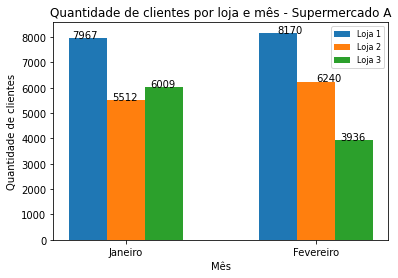

In [18]:
# Grafico
# Supermercado A
# Definir as posições das barras no eixo x
posicoes = np.arange(2)

quantidade_loja1 = [df_jan_superA_client_qtd[0] , df_fev_superA_client_qtd[0]]
quantidade_loja2 = [df_jan_superA_client_qtd[1] , df_fev_superA_client_qtd[1]]
quantidade_loja3 = [df_jan_superA_client_qtd[2] , df_fev_superA_client_qtd[2]]

# Criar o gráfico de barras
plt.bar(posicoes - 0.2, quantidade_loja1, width=0.2, label='Loja 1')
plt.bar(posicoes, quantidade_loja2, width=0.2, label='Loja 2')
plt.bar(posicoes + 0.2, quantidade_loja3, width=0.2, label='Loja 3')


# Adiciona rótulos às barras
plt.text(posicoes[0] - 0.28, quantidade_loja1[0] + 1, str(quantidade_loja1[0]))
plt.text(posicoes[0] - 0.07, quantidade_loja2[0] + 1, str(quantidade_loja2[0]))
plt.text(posicoes[0] + 0.13, quantidade_loja3[0] + 1, str(quantidade_loja3[0]))

plt.text(posicoes[1] - 0.2, quantidade_loja1[1] + 1, str(quantidade_loja1[1]))
plt.text(posicoes[1], quantidade_loja2[1] + 1, str(quantidade_loja2[1]))
plt.text(posicoes[1] + 0.13, quantidade_loja3[1] + 1, str(quantidade_loja3[1]))


# Adicionar legendas e títulos
plt.xlabel('Mês')
plt.ylabel('Quantidade de clientes')
plt.title('Quantidade de clientes por loja e mês - Supermercado A')
plt.xticks(posicoes, ['Janeiro', 'Fevereiro'])
plt.legend(fontsize=8)

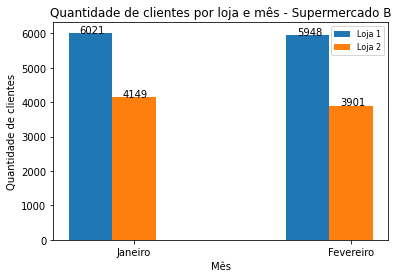

In [19]:
# Grafico
# Supermercado A
# Definir as posições das barras no eixo x
posicoes = np.arange(2)

quantidade_loja1 = [df_jan_superB_client_qtd[0] , df_fev_superB_client_qtd[0]]
quantidade_loja2 = [df_jan_superB_client_qtd[1] , df_fev_superB_client_qtd[1]]

# Criar o gráfico de barras
plt.bar(posicoes - 0.2, quantidade_loja1, width=0.2, label='Loja 1')
plt.bar(posicoes, quantidade_loja2, width=0.2, label='Loja 2')


# Adiciona rótulos às barras
plt.text(posicoes[0] - 0.25, quantidade_loja1[0] + 1, str(quantidade_loja1[0]))
plt.text(posicoes[0] - 0.05, quantidade_loja2[0] + 1, str(quantidade_loja2[0]))

plt.text(posicoes[1] - 0.25, quantidade_loja1[1] + 1, str(quantidade_loja1[1]))
plt.text(posicoes[1] - 0.05, quantidade_loja2[1] + 1, str(quantidade_loja2[1]))


# Adicionar legendas e títulos
plt.xlabel('Mês')
plt.ylabel('Quantidade de clientes')
plt.title('Quantidade de clientes por loja e mês - Supermercado B')
plt.xticks(posicoes, ['Janeiro', 'Fevereiro'])
plt.legend(fontsize=8)

Conclusão:
- Supermercado A: Leve alteração de janeiro para fevereiro por conta da loja 3, o que representa em 5% de churn entre jan e fev
- Supermercado B: Todas lojas do supermercado B tiveram churn entre janeiro e fev, totalizando 3% de churn entre jan e fev

### 4 – Com o diagnóstico obtido até aqui, quais recomendações você forneceria aos times de marketing, operações e comercial das redes?

Conclusão:
- Ambos supermercados demostraram que a categoria que tem maior representativade no faturamento são as Bebidas. Dessa forma recomendo ações para vendas mais bebidas, e utilizar essa procura dos usuarios para conseguir vender outras categorias. Alem de se preparar em termos de estoque pois é uma categoria que vem crescendo a procura